# Noise Generators Comparison

This notebook compares all 8 noise generators in the AudioPlayground engine:

1. **White Noise** - Flat spectrum, harsh sound
2. **Pink Noise** - 1/f spectrum, perceptually balanced
3. **Brownian Noise** - 1/f² spectrum, deep rumble
4. **Blue Noise** - +3dB/octave, bright and airy
5. **Perlin Noise** - Smooth, organic modulation
6. **Velvet Noise** - Sparse impulses, efficient for reverb
7. **Grey Noise** - Psychoacoustically flat
8. **Sample & Hold Noise** - Stepped random values

We'll analyze:,
- Time domain characteristics,
- Power Spectral Density (PSD)
- Statistical properties
- Audio playback

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display
from scipy import signal

from engine import (
    white_noise,
    pink_noise,
    brownian_noise,
    blue_noise,
    perlin_noise,
    velvet_noise,
    grey_noise,
    sample_hold_noise
)

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✅ Imports successful!")


✅ Imports successful!


## 1. Generate Noise Samples

Generate 2 seconds of each noise type at 44.1kHz sample rate.

In [17]:
# Parameters
duration = 2.0  # seconds
sample_rate = 44100  # Hz
amplitude = 0.5  # Keep it moderate for listening
seed = 42  # For reproducibility

# Generate all noise types
print("Generating noise samples...\n")

noise_samples = {
    'White': white_noise(duration, amplitude, sample_rate, seed),
    'Pink': pink_noise(duration, amplitude, sample_rate, seed),
    'Brownian': brownian_noise(duration, amplitude, sample_rate, seed),
    'Blue': blue_noise(duration, amplitude, sample_rate, seed),
    'Perlin': perlin_noise(duration, scale=20, sr=sample_rate, seed=seed) * amplitude / 8,  # Scale to amplitude
    'Velvet': velvet_noise(duration, density=0.01, amplitude=amplitude, sr=sample_rate, seed=seed),
    'Grey': grey_noise(duration, amplitude, sample_rate, seed),
    'Sample & Hold': sample_hold_noise(duration, rate=10, amplitude=amplitude, sr=sample_rate, seed=seed)
}

# Print statistics
for name, samples in noise_samples.items():
    print(f"{name:<20} Length: {len(samples):>7} Range: [{samples.min():>7.3f}, {samples.max():>7.3f}]  "
          f"Mean: {samples.mean():>7.3f}  Std: {samples.std():>6.3f}")

print(f"\n✅ Generated {len(noise_samples)} noise types ({duration}s each at {sample_rate}Hz)")

Generating noise samples...

White                Length:   88200  Range: [ -0.500,   0.500]  Mean:   0.000  Std:  0.288
Pink                 Length:   88200  Range: [ -0.305,   0.279]  Mean:  -0.006  Std:  0.071
Brownian             Length:   88200  Range: [ -0.500,   0.290]  Mean:  -0.147  Std:  0.164
Blue                 Length:   88200  Range: [ -0.500,   0.499]  Mean:   0.000  Std:  0.204
Perlin               Length:   88200  Range: [ -0.250,   0.250]  Mean:   0.000  Std:  0.080
Velvet               Length:   88200  Range: [ -0.500,   0.500]  Mean:  -0.000  Std:  0.050
Grey                 Length:   88200  Range: [ -0.500,   0.486]  Mean:   0.000  Std:  0.179
Sample & Hold        Length:   88200  Range: [ -0.479,   0.470]  Mean:  -0.042  Std:  0.300

✅ Generated 8 noise types (2.0s each at 44100Hz)


## 2. Time Domain Visualization

Plot the first 0.1 seconds of each noise type to see their time-domain characteristics.

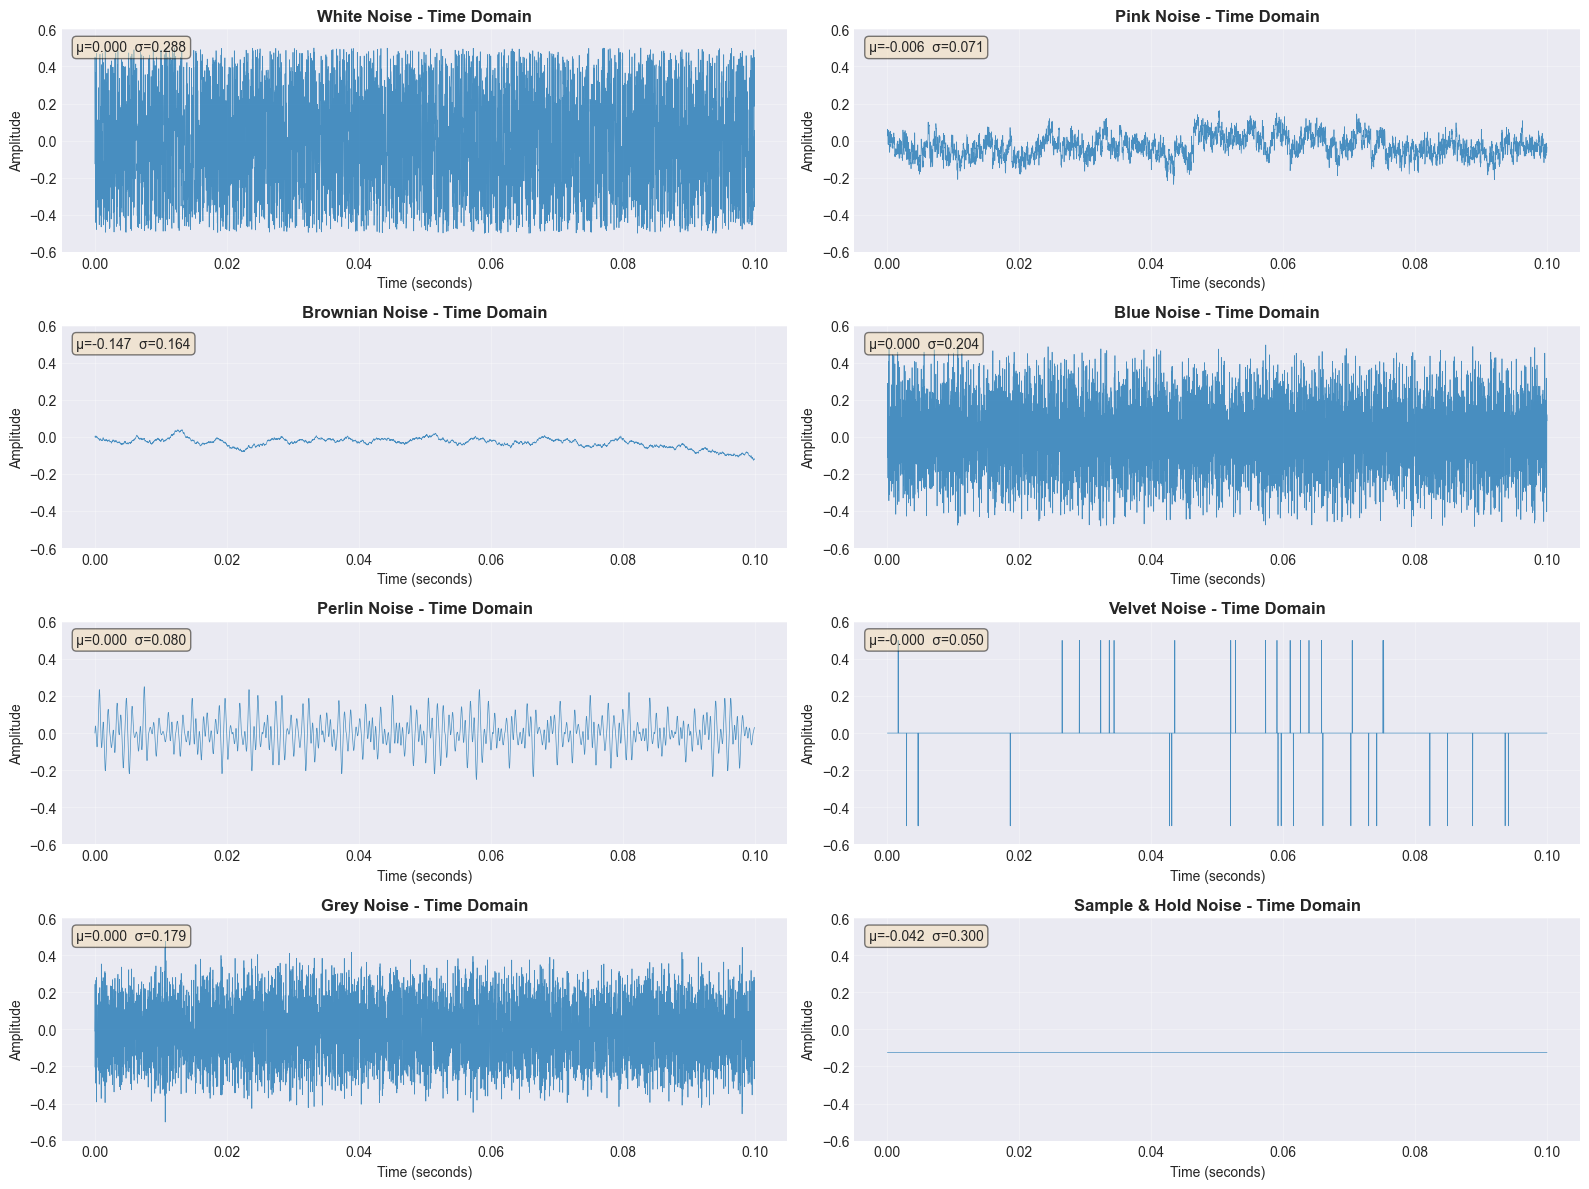

✅ Time domain plots generated


In [3]:
# Plot time domain (first 0.1 seconds)
plot_duration = 0.1  # seconds
plot_samples = int(plot_duration * sample_rate)
time_axis = np.linspace(0, plot_duration, plot_samples)

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, samples) in enumerate(noise_samples.items()):
    ax = axes[idx]
    ax.plot(time_axis, samples[:plot_samples], linewidth=0.5, alpha=0.8)
    ax.set_title(f'{name} Noise - Time Domain', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.6, 0.6)
    
    # Add stats
    stats_text = f"μ={samples.mean():.3f}  σ={samples.std():.3f}"
    ax.text(0.02, 0.95, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('noise_time_domain.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Time domain plots generated")

## 3. Power Spectral Density (PSD) Analysis

Analyze the frequency content of each noise type using Welch's method.

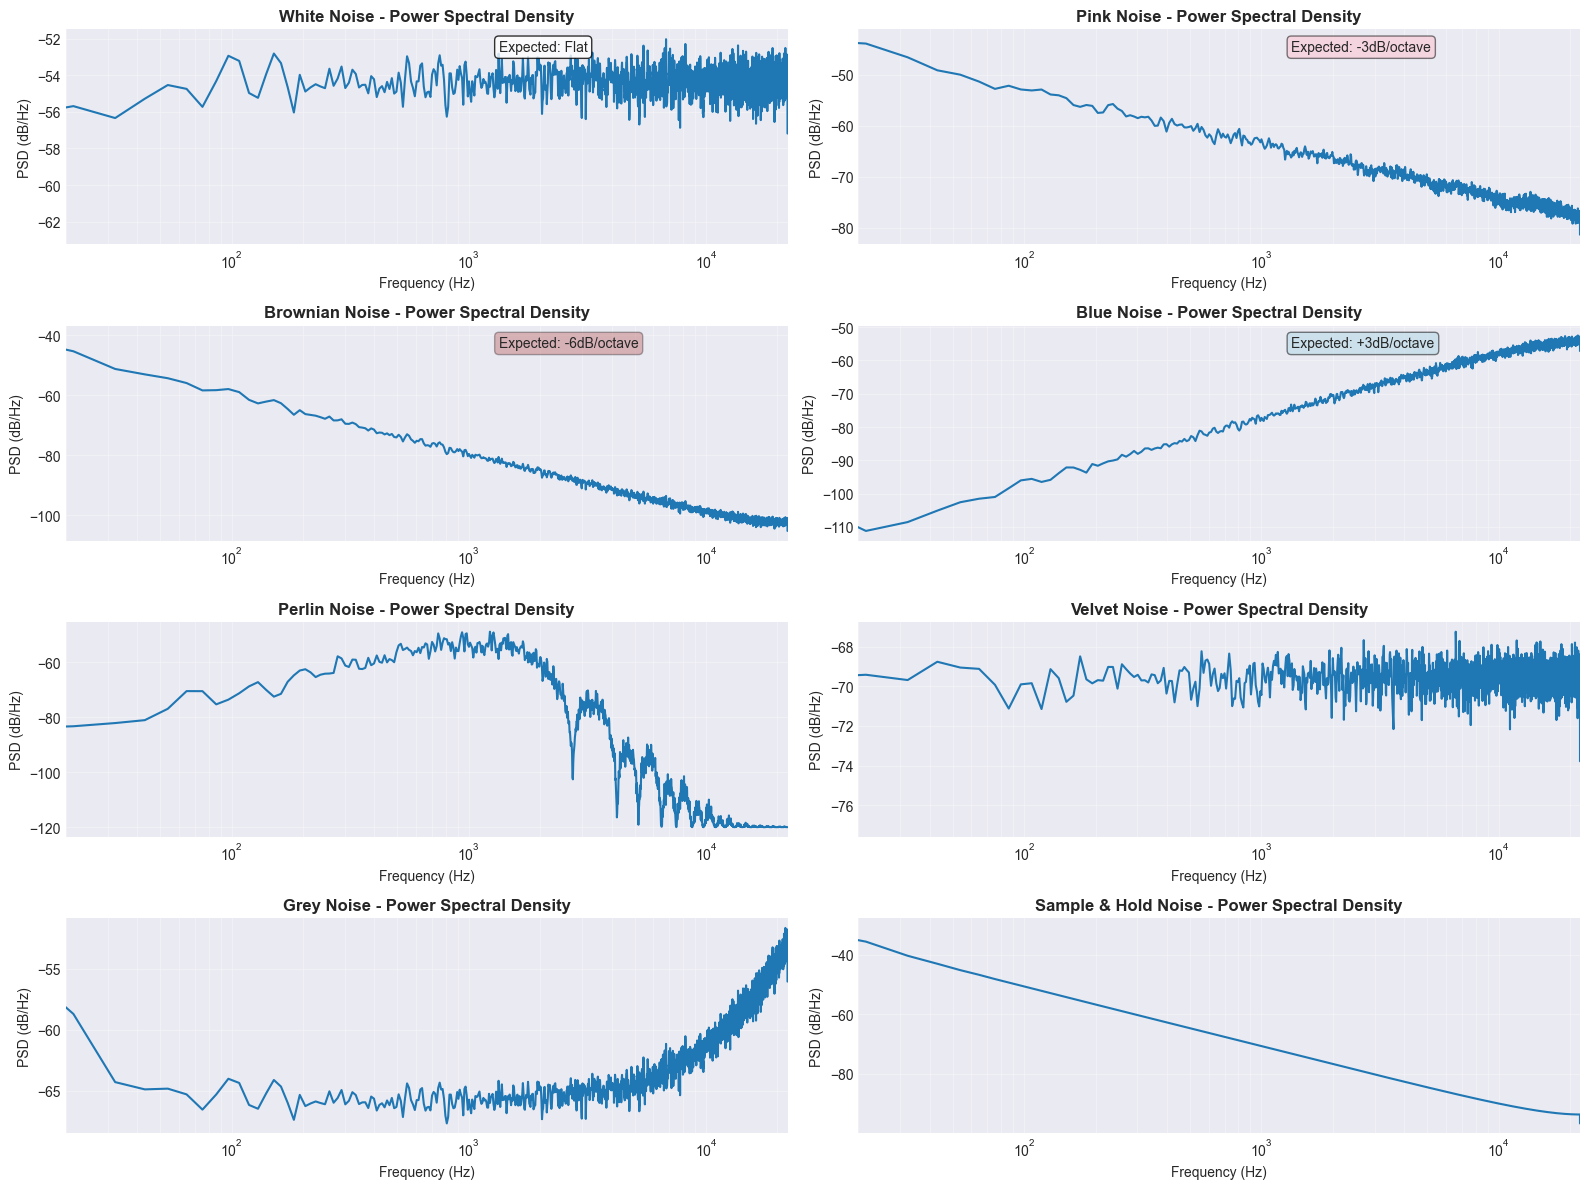

✅ PSD plots generated


In [4]:
# Calculate PSD for all noise types
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, samples) in enumerate(noise_samples.items()):
    ax = axes[idx]
    
    # Compute PSD using Welch's method
    frequencies, psd = signal.welch(samples, sample_rate, nperseg=4096)
    
    # Plot in dB scale
    psd_db = 10 * np.log10(psd + 1e-12)  # Avoid log(0)
    
    ax.semilogx(frequencies, psd_db, linewidth=1.5)
    ax.set_title(f'{name} Noise - Power Spectral Density', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (dB/Hz)')
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim(20, sample_rate/2)
    
    # Add theoretical slope for colored noise
    if name == 'Pink':
        ax.text(0.6, 0.95, 'Expected: -3dB/octave', transform=ax.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='pink', alpha=0.5))
    elif name == 'Brownian':
        ax.text(0.6, 0.95, 'Expected: -6dB/octave', transform=ax.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='brown', alpha=0.3))
    elif name == 'Blue':
        ax.text(0.6, 0.95, 'Expected: +3dB/octave', transform=ax.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    elif name == 'White':
        ax.text(0.6, 0.95, 'Expected: Flat', transform=ax.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('noise_psd.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ PSD plots generated")

## 4. Spectral Slope Analysis

Compare the spectral slopes of different noise types on a single plot.

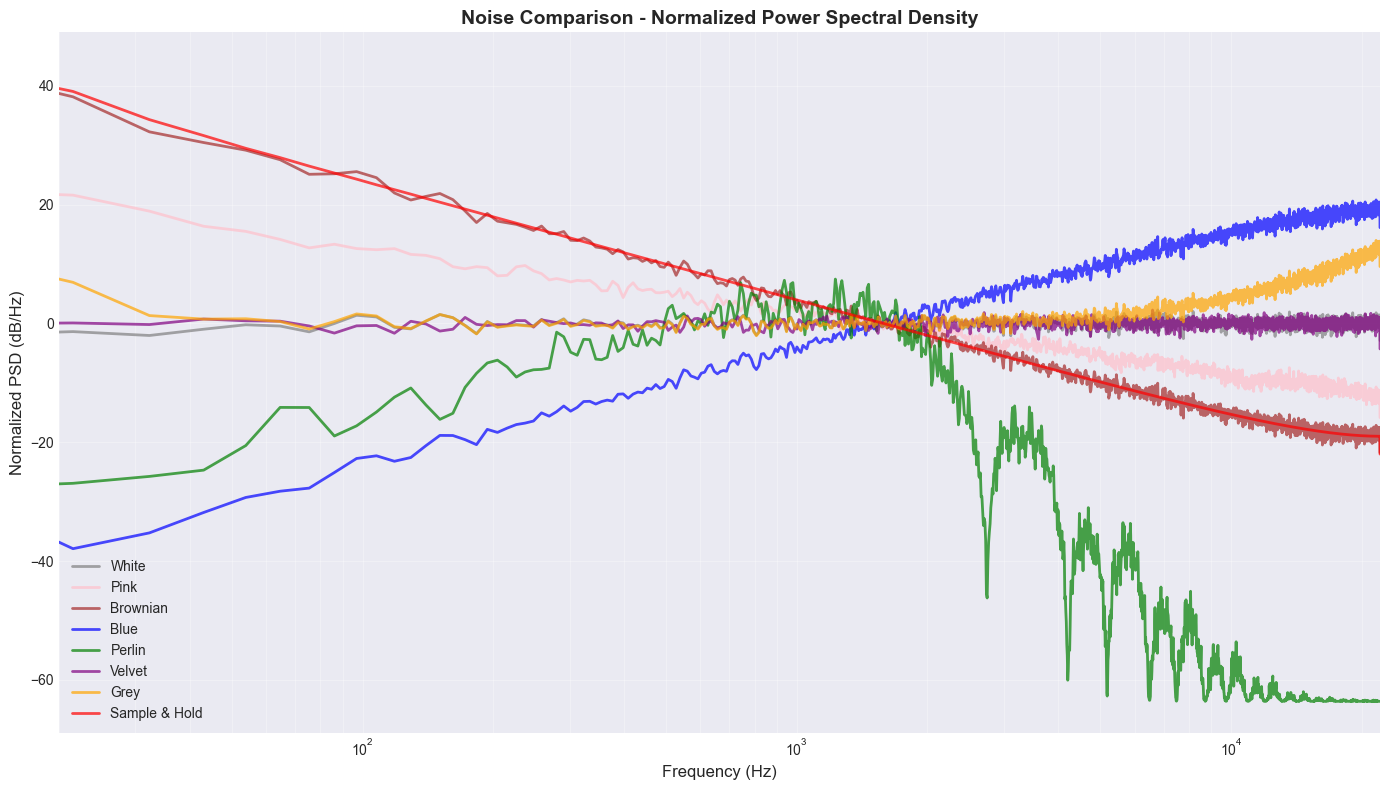

✅ Comparative PSD plot generated


In [5]:
# Compare all PSDs on one plot
plt.figure(figsize=(14, 8))

colors = ['gray', 'pink', 'brown', 'blue', 'green', 'purple', 'orange', 'red']

for (name, samples), color in zip(noise_samples.items(), colors):
    frequencies, psd = signal.welch(samples, sample_rate, nperseg=4096)
    psd_db = 10 * np.log10(psd + 1e-12)
    
    # Normalize for comparison
    psd_db_norm = psd_db - np.mean(psd_db[100:200])  # Normalize around 1kHz
    
    plt.semilogx(frequencies, psd_db_norm, label=name, linewidth=2, color=color, alpha=0.7)

plt.title('Noise Comparison - Normalized Power Spectral Density', fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Normalized PSD (dB/Hz)', fontsize=12)
plt.grid(True, alpha=0.3, which='both')
plt.legend(loc='best', fontsize=10)
plt.xlim(20, sample_rate/2)
plt.tight_layout()
plt.savefig('noise_psd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Comparative PSD plot generated")

## 5. Histogram Analysis

Analyze the amplitude distribution of each noise type.

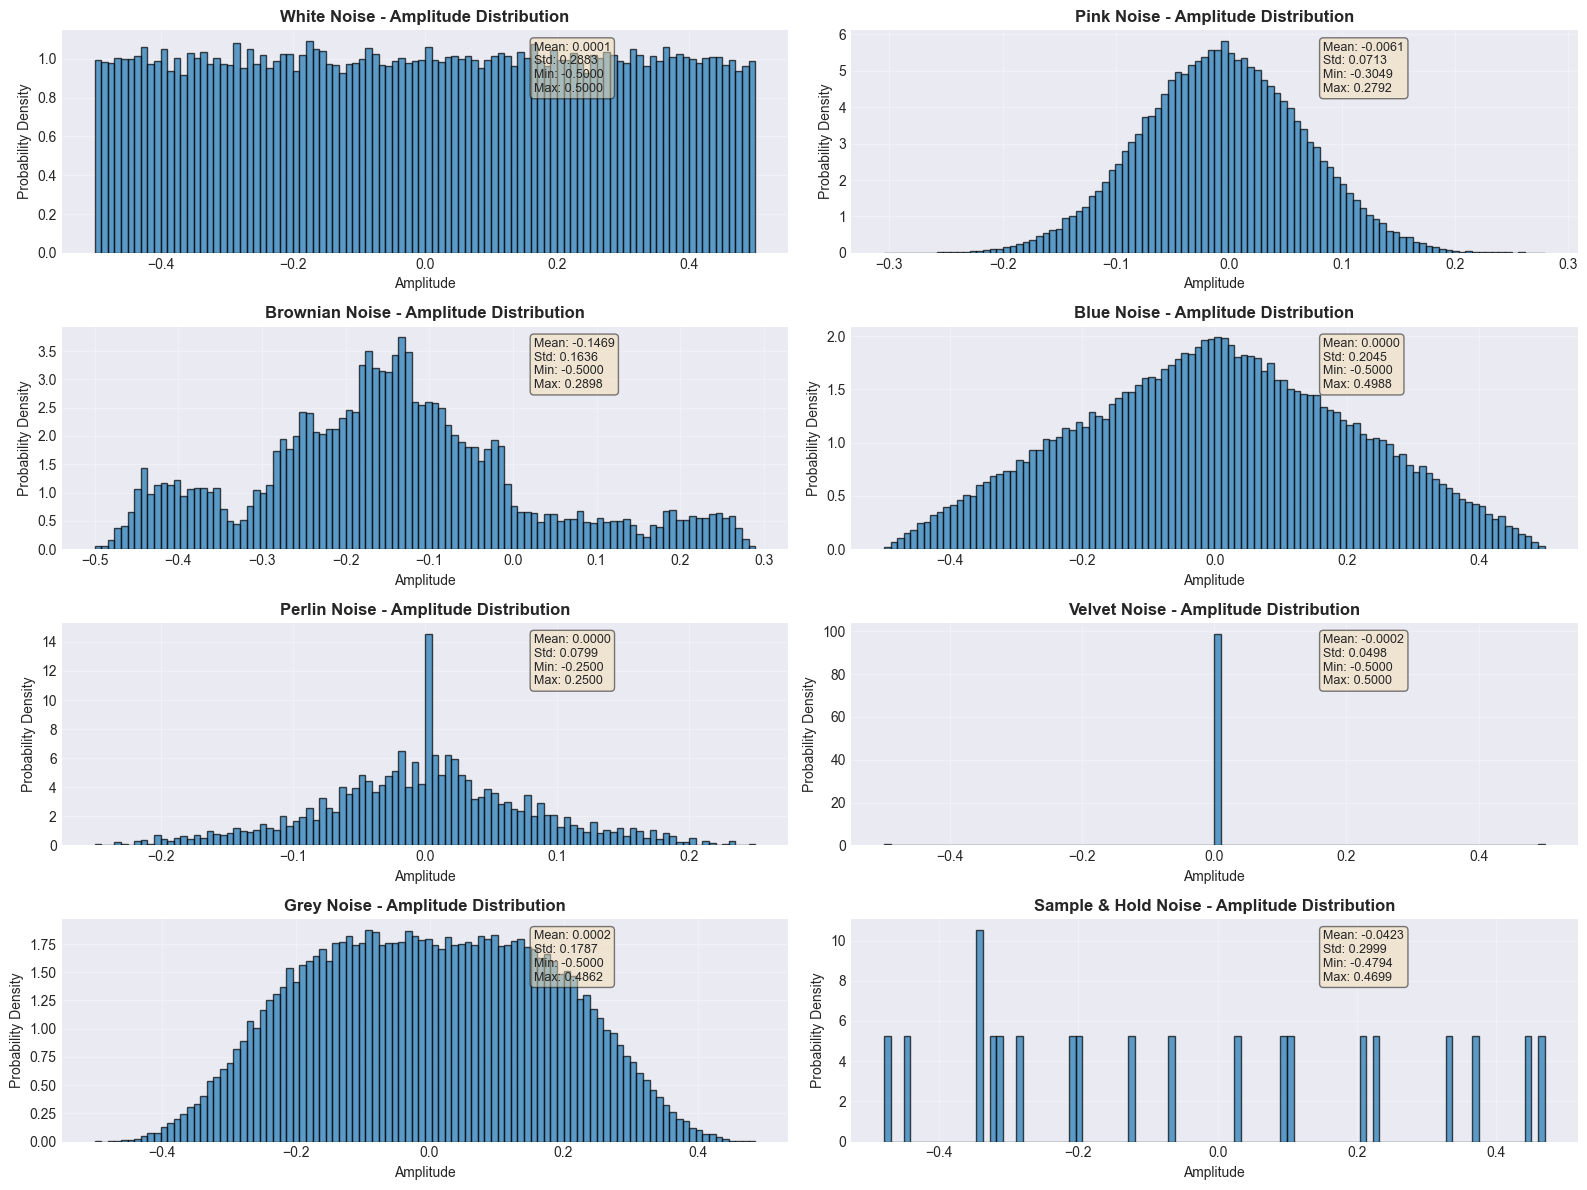

✅ Histogram plots generated


In [6]:
# Amplitude distribution histograms
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, samples) in enumerate(noise_samples.items()):
    ax = axes[idx]
    
    # Create histogram
    counts, bins, patches = ax.hist(samples, bins=100, density=True, alpha=0.7, edgecolor='black')
    
    ax.set_title(f'{name} Noise - Amplitude Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Amplitude')
    ax.set_ylabel('Probability Density')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    stats_text = (f"Mean: {samples.mean():.4f}\n"
                  f"Std: {samples.std():.4f}\n"
                  f"Min: {samples.min():.4f}\n"
                  f"Max: {samples.max():.4f}")
    ax.text(0.65, 0.95, stats_text, transform=ax.transAxes,
            verticalalignment='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('noise_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Histogram plots generated")

## 6. Special Characteristics

Highlight unique characteristics of specific noise types.

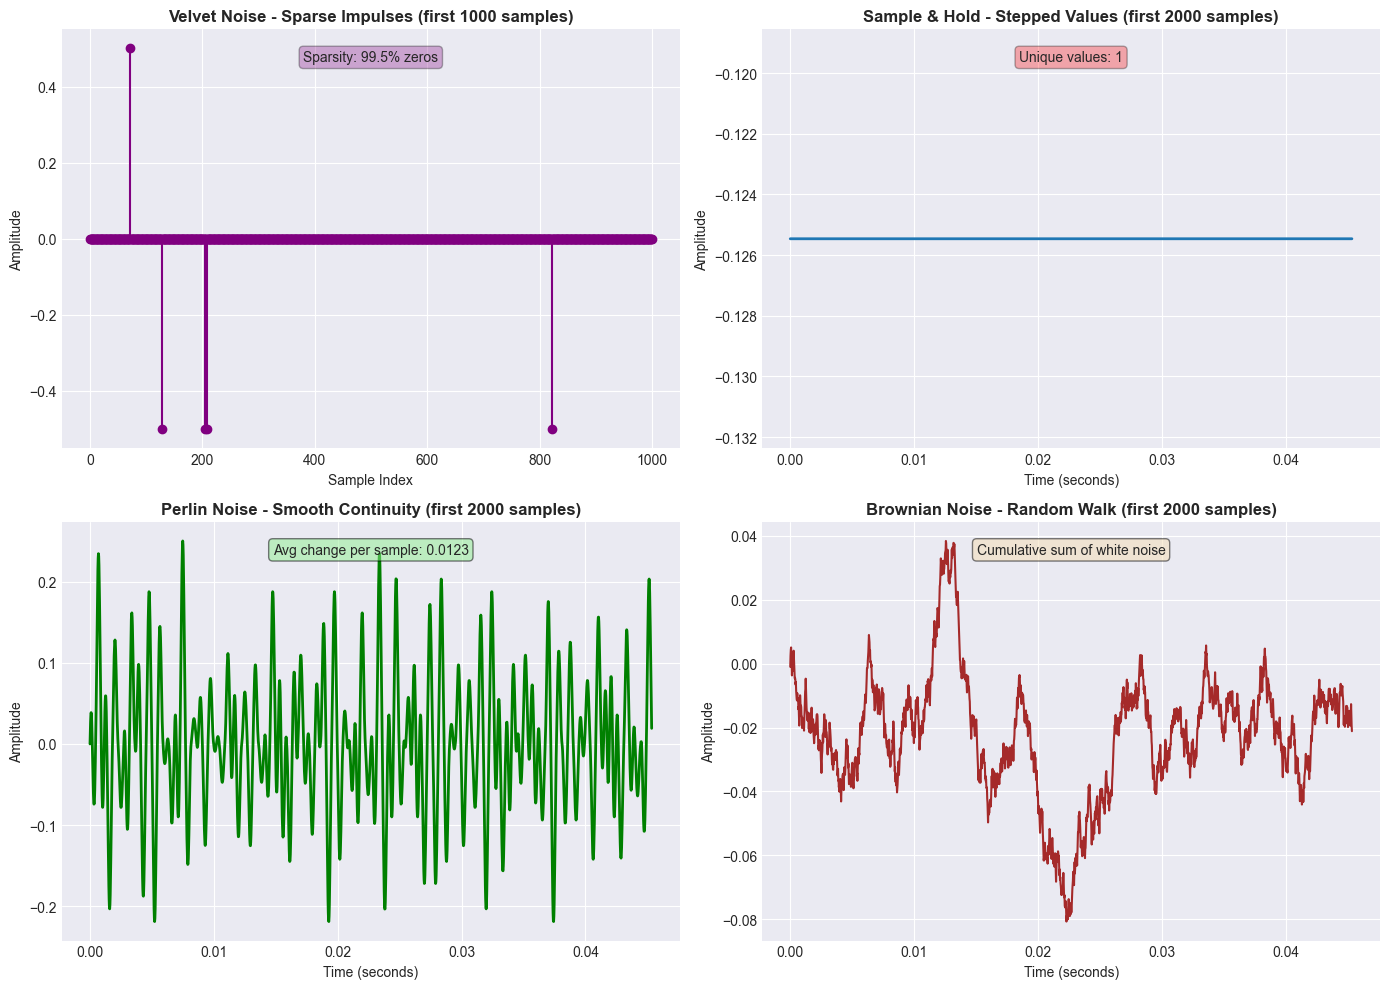

✅ Special characteristics plots generated


In [7]:
# Special characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Velvet Noise - Show sparsity
ax = axes[0, 0]
velvet_snippet = noise_samples['Velvet'][:1000]
ax.stem(np.arange(len(velvet_snippet)), velvet_snippet, linefmt='purple', markerfmt='o', basefmt=' ')
ax.set_title('Velvet Noise - Sparse Impulses (first 1000 samples)', fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Amplitude')
non_zero = np.count_nonzero(velvet_snippet)
ax.text(0.5, 0.95, f'Sparsity: {(1-non_zero/len(velvet_snippet))*100:.1f}% zeros',
        transform=ax.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='purple', alpha=0.3))

# 2. Sample & Hold - Show steps
ax = axes[0, 1]
sh_snippet = noise_samples['Sample & Hold'][:2000]
time_snippet = np.linspace(0, 2000/sample_rate, len(sh_snippet))
ax.plot(time_snippet, sh_snippet, linewidth=2, drawstyle='steps-post')
ax.set_title('Sample & Hold - Stepped Values (first 2000 samples)', fontweight='bold')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude')
unique_vals = len(np.unique(sh_snippet))
ax.text(0.5, 0.95, f'Unique values: {unique_vals}',
        transform=ax.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

# 3. Perlin Noise - Smooth continuity
ax = axes[1, 0]
perlin_snippet = noise_samples['Perlin'][:2000]
time_snippet = np.linspace(0, 2000/sample_rate, len(perlin_snippet))
ax.plot(time_snippet, perlin_snippet, linewidth=2, color='green')
ax.set_title('Perlin Noise - Smooth Continuity (first 2000 samples)', fontweight='bold')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude')
# Calculate smoothness (average absolute derivative)
smoothness = np.mean(np.abs(np.diff(perlin_snippet)))
ax.text(0.5, 0.95, f'Avg change per sample: {smoothness:.4f}',
        transform=ax.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# 4. Brownian Noise - Random walk
ax = axes[1, 1]
brown_snippet = noise_samples['Brownian'][:2000]
time_snippet = np.linspace(0, 2000/sample_rate, len(brown_snippet))
ax.plot(time_snippet, brown_snippet, linewidth=1.5, color='brown')
ax.set_title('Brownian Noise - Random Walk (first 2000 samples)', fontweight='bold')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude')
# Calculate drift (cumulative nature)
ax.text(0.5, 0.95, 'Cumulative sum of white noise',
        transform=ax.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('noise_special_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Special characteristics plots generated")


## 7. Audio Playback

Listen to each noise type (2 seconds each).

**Note:** Adjust your volume to a comfortable level before playing!

In [8]:
# Create audio players for each noise type
print("🔊 Audio Players for Each Noise Type\n")
print("Adjust your volume before playing!\n")

for name, samples in noise_samples.items():
    print(f"\n{'='*60}")
    print(f"🎵 {name} Noise")
    print(f"{'='*60}")
    
    # Normalize to prevent clipping
    max_val = np.max(np.abs(samples))
    if max_val > 0:
        normalized = samples / max_val * 0.5  # Keep at 50% to be safe
    else:
        normalized = samples
    
    # Create audio player
    display(Audio(normalized, rate=sample_rate))

print("\n✅ All audio players created")

🔊 Audio Players for Each Noise Type

Adjust your volume before playing!


🎵 White Noise



🎵 Pink Noise



🎵 Brownian Noise



🎵 Blue Noise



🎵 Perlin Noise



🎵 Velvet Noise



🎵 Grey Noise



🎵 Sample & Hold Noise



✅ All audio players created


## 8. Summary Table

Comprehensive comparison of all noise characteristics.

In [9]:
import pandas as pd

# Calculate statistics for all noise types
stats_data = []

for name, samples in noise_samples.items():
    # Calculate statistics
    frequencies, psd = signal.welch(samples, sample_rate, nperseg=4096)
    
    # Estimate spectral slope (in 100-1000 Hz range)
    freq_range = (frequencies >= 100) & (frequencies <= 1000)
    if np.any(freq_range):
        freq_log = np.log10(frequencies[freq_range])
        psd_log = 10 * np.log10(psd[freq_range] + 1e-12)
        slope = np.polyfit(freq_log, psd_log, 1)[0]
    else:
        slope = 0
    
    stats_data.append({
        'Noise Type': name,
        'Mean': f"{samples.mean():.4f}",
        'Std Dev': f"{samples.std():.4f}",
        'Min': f"{samples.min():.4f}",
        'Max': f"{samples.max():.4f}",
        'Spectral Slope (dB/decade)': f"{slope:.2f}",
        'Sparsity (% zeros)': f"{(1 - np.count_nonzero(samples)/len(samples))*100:.1f}%" if name == 'Velvet' else 'N/A'
    })

# Create DataFrame
df = pd.DataFrame(stats_data)

print("\n" + "="*100)
print("NOISE GENERATORS - COMPREHENSIVE COMPARISON")
print("="*100)
print(df.to_string(index=False))
print("="*100)

# Save to CSV
df.to_csv('noise_comparison_stats.csv', index=False)
print("\n✅ Statistics saved to 'noise_comparison_stats.csv'")


NOISE GENERATORS - COMPREHENSIVE COMPARISON
   Noise Type    Mean Std Dev     Min    Max Spectral Slope (dB/decade) Sparsity (% zeros)
        White  0.0001  0.2883 -0.5000 0.5000                       0.00                N/A
         Pink -0.0061  0.0713 -0.3049 0.2792                     -10.28                N/A
     Brownian -0.1469  0.1636 -0.5000 0.2898                     -20.03                N/A
         Blue  0.0000  0.2045 -0.5000 0.4988                      19.99                N/A
       Perlin  0.0000  0.0799 -0.2500 0.2500                      19.66                N/A
       Velvet -0.0002  0.0498 -0.5000 0.5000                      -0.21              99.0%
         Grey  0.0002  0.1787 -0.5000 0.4862                      -0.13                N/A
Sample & Hold -0.0423  0.2999 -0.4794 0.4699                     -20.02                N/A

✅ Statistics saved to 'noise_comparison_stats.csv'


## 9. Use Case Recommendations

Based on the characteristics analyzed above.

In [10]:
use_cases = {
    'White Noise': [
        '🥁 Percussion synthesis (snare, hi-hat)',
        '🔬 Audio testing and calibration',
        '🎚️ Dithering in digital audio'
    ],
    'Pink Noise': [
        '🌊 Ambient soundscapes (wind, waterfalls)',
        '🎵 Natural-sounding textures',
        '🔊 Room acoustics testing'
    ],
    'Brownian Noise': [
        '🔊 Sub-bass rumble and thunder',
        '🌊 Ocean waves simulation',
        '📉 Low-frequency modulation source'
    ],
    'Blue Noise': [
        '✨ Bright shimmer effects',
        '💨 Steam and spray sounds',
        '🎆 High-frequency textures'
    ],
    'Perlin Noise': [
        '🎛️ Smooth LFO for vibrato/tremolo',
        '🎨 Organic parameter automation',
        '🌅 Evolving ambient pads'
    ],
    'Velvet Noise': [
        '🎙️ Convolution reverb impulse responses',
        '🏛️ Room simulation (very efficient)',
        '⚡ Fast reverb processing'
    ],
    'Grey Noise': [
        '🔬 Psychoacoustic testing',
        '🎧 Masking experiments',
        '📊 Perceptually neutral reference'
    ],
    'Sample & Hold': [
        '🎹 Vintage synthesizer random LFO',
        '🤖 Robotic/stepped modulation',
        '⚡ Glitch and lo-fi effects'
    ]
}

print("\\n" + "="*80)
print("RECOMMENDED USE CASES")
print("="*80)

for noise_type, cases in use_cases.items():
    print(f"\\n{noise_type}:")
    for case in cases:
        print(f"  {case}")

print("\\n" + "="*80)

\n================================================================================
RECOMMENDED USE CASES
\nWhite Noise:
  🥁 Percussion synthesis (snare, hi-hat)
  🔬 Audio testing and calibration
  🎚️ Dithering in digital audio
\nPink Noise:
  🌊 Ambient soundscapes (wind, waterfalls)
  🎵 Natural-sounding textures
  🔊 Room acoustics testing
\nBrownian Noise:
  🔊 Sub-bass rumble and thunder
  🌊 Ocean waves simulation
  📉 Low-frequency modulation source
\nBlue Noise:
  ✨ Bright shimmer effects
  💨 Steam and spray sounds
  🎆 High-frequency textures
\nPerlin Noise:
  🎛️ Smooth LFO for vibrato/tremolo
  🎨 Organic parameter automation
  🌅 Evolving ambient pads
\nVelvet Noise:
  🎙️ Convolution reverb impulse responses
  🏛️ Room simulation (very efficient)
  ⚡ Fast reverb processing
\nGrey Noise:
  🔬 Psychoacoustic testing
  🎧 Masking experiments
  📊 Perceptually neutral reference
\nSample & Hold:
  🎹 Vintage synthesizer random LFO
  🤖 Robotic/stepped modulation
  ⚡ Glitch and lo-fi effects
\n==

## 10. Spectrograms

Visualize the time-frequency characteristics of each noise type.

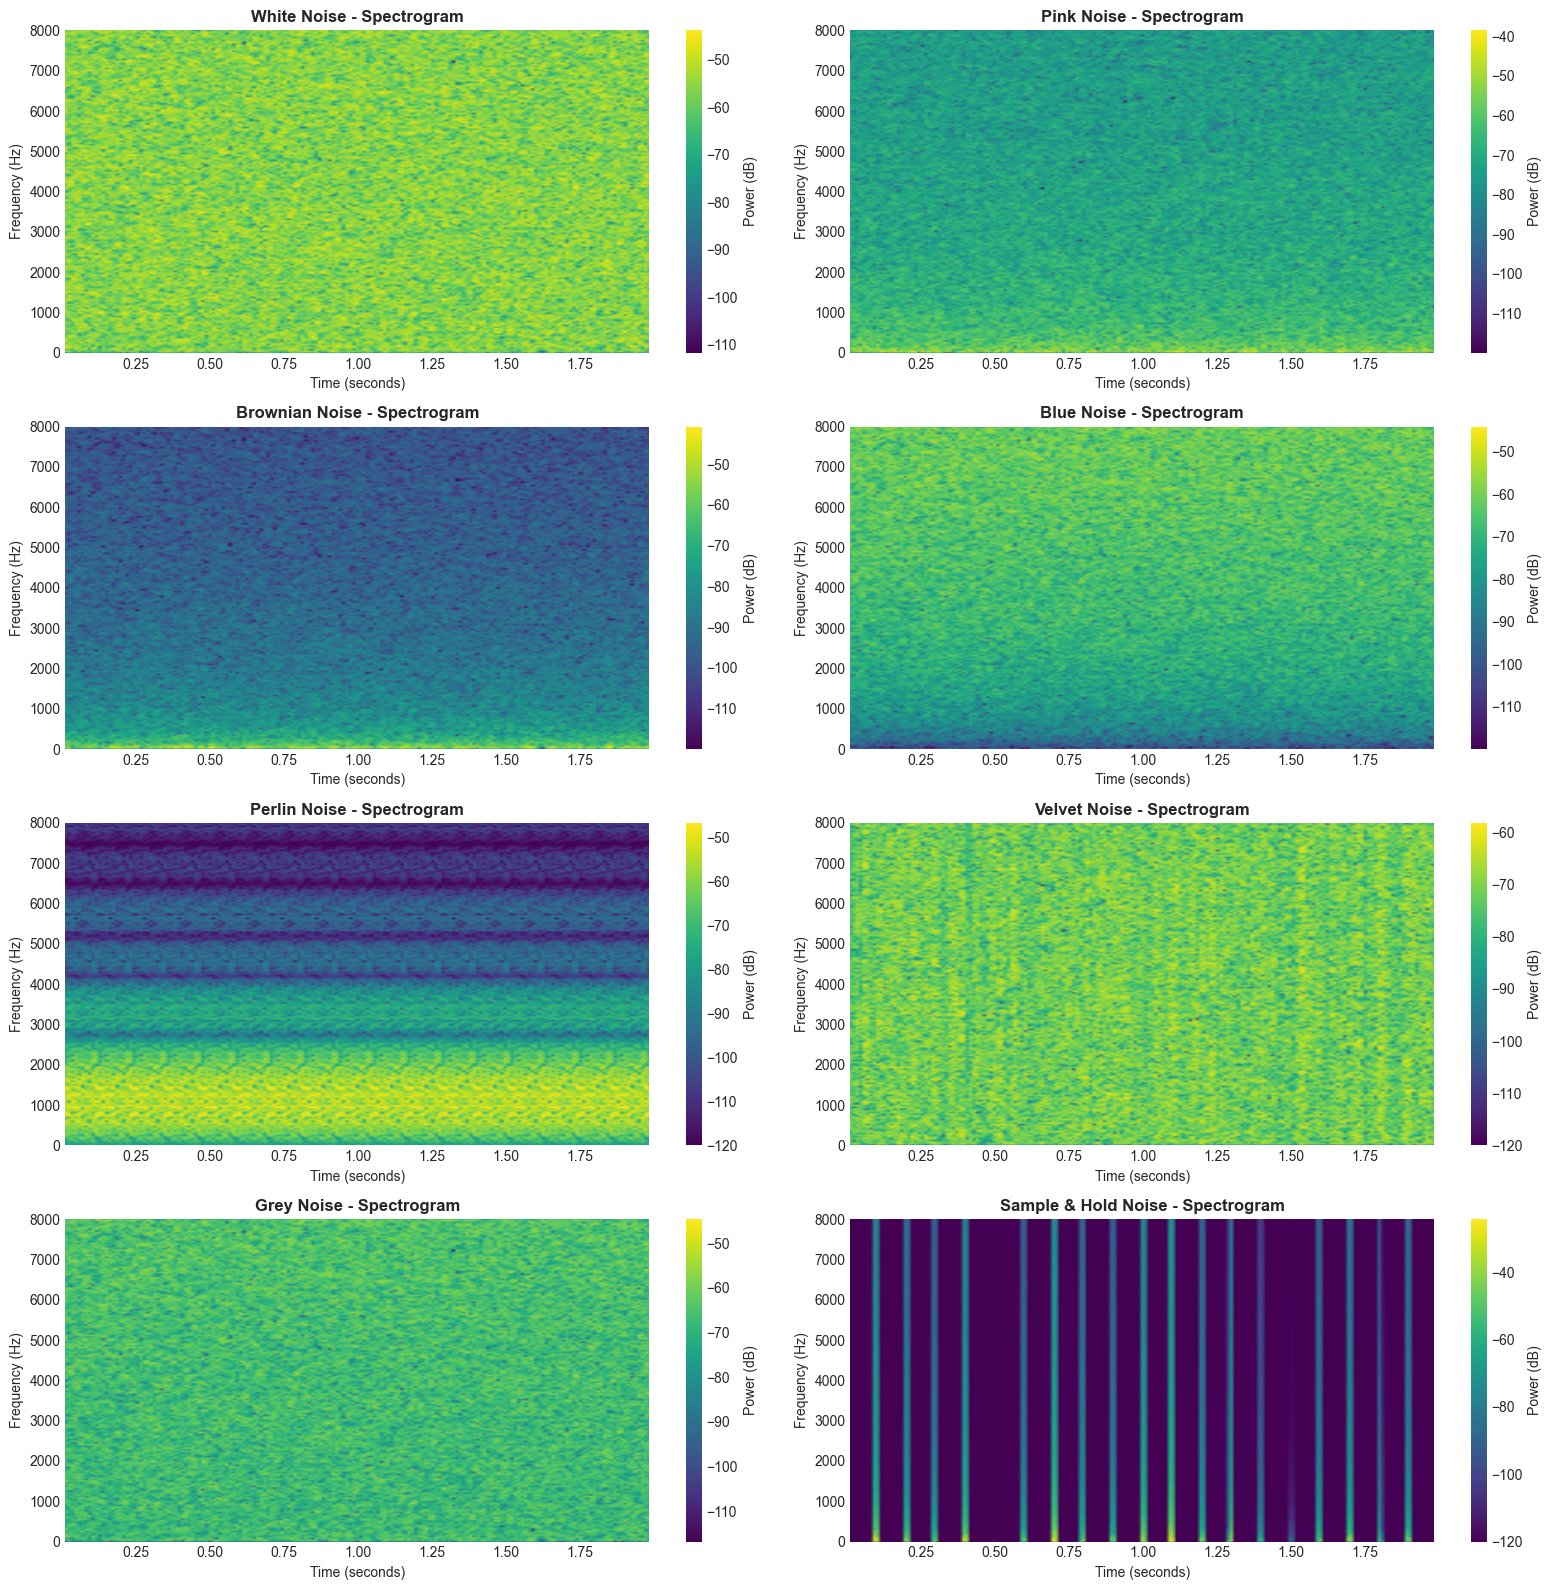

✅ Spectrogram plots generated


In [12]:
# Create spectrograms
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for idx, (name, samples) in enumerate(noise_samples.items()):
    ax = axes[idx]
    
    # Compute spectrogram
    f, t, Sxx = signal.spectrogram(samples, sample_rate, nperseg=1024, noverlap=512)
    
    # Plot in dB scale
    Sxx_db = 10 * np.log10(Sxx + 1e-12)
    
    im = ax.pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='viridis')
    ax.set_title(f'{name} Noise - Spectrogram', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_ylim(0, 8000)  # Focus on 0-8kHz
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Power (dB)')

plt.tight_layout()
plt.savefig('noise_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Spectrogram plots generated")

## Summary

This notebook has demonstrated:

1. ✅ **Time Domain Analysis** - Temporal characteristics of each noise type
2. ✅ **Power Spectral Density** - Frequency content and spectral slopes
3. ✅ **Amplitude Distribution** - Statistical properties and histograms
4. ✅ **Special Characteristics** - Unique features (sparsity, steps, smoothness)
5. ✅ **Audio Playback** - Direct listening comparison
6. ✅ **Comprehensive Statistics** - Quantitative comparison table
7. ✅ **Use Cases** - Practical applications for each noise type
8. ✅ **Spectrograms** - Time-frequency visualization

### Key Findings:

- **White Noise**: Flat spectrum, truly random, harsh sound
- **Pink Noise**: -3dB/octave slope, perceptually balanced
- **Brownian Noise**: -6dB/octave slope, heavy in bass
- **Blue Noise**: +3dB/octave slope, bright and airy
- **Perlin Noise**: Smooth, continuous, organic modulation
- **Velvet Noise**: 99% sparse, flat spectrum, efficient
- **Grey Noise**: Psychoacoustically flat, perceptually neutral
- **Sample & Hold**: Stepped values, vintage synth character

### Generated Files:

- `noise_time_domain.png` - Time domain plots
- `noise_psd.png` - Individual PSD plots
- `noise_psd_comparison.png` - Comparative PSD plot
- `noise_histograms.png` - Amplitude distributions
- `noise_special_characteristics.png` - Unique features
- `noise_spectrograms.png` - Time-frequency analysis
- `noise_comparison_stats.csv` - Statistical comparison table

---

**AudioPlayground Noise Module** - Production-ready noise generators for audio synthesis! 🎉